# Market - sentiment independence

In [7]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ..data.model_data import return_data
from ..data.sentiment import return_sentiment_chunk_data
import pandas as pd

In [10]:
print(return_sentiment_chunk_data().sample(20).to_csv())

,date,part,is_question,chunk,score,sentiment_model,topic,topic_prob
8964,2006-02-02,QA,0,"On the first question: We are looking at what is necessary for Europe. We have been credible since the setting‑up of the euro seven years ago. And, as we have always said, and as my predecessor always said, we incorporate all pertinent information to see what the risks to price stability are and what the appropriate response is in order to cope with those risks. Again, delivering price stability and being credible over time in delivering price stability – there is no other consideration.",0.0942610027268529,finbert,MONETARY_POLICY_AND_INFLATION,0.6614875197410583
22579,2013-10-02,QA,0,"I am just going to correct you a little bit. The article talks about changes in the regime, not in the levels of exchange rates. And the regime has been approved – the euro is a floating currency, and there has been no discussion whatsoever, or willingness of anyone to change that regime. And that is what the Treaty

In [2]:
WITH_LABEL = False
data = return_data(
    IS_QA_division=False,
    qa_options="both_together",
    with_label=WITH_LABEL,
    word_limit=1,
    market_data="all",
).set_index("date")
sentiment_columns = (
    data[
        sorted(
            [
                c
                for c in list(data.columns)
                if any(x in c for x in ["finbert", "roberta"])
            ],
            key=lambda x: tuple(reversed(x.split("_"))),
        )
    ]
).columns

In [6]:
print(data.describe()[["finbert_mean","roberta_mean"]].to_csv())

,finbert_mean,roberta_mean
count,272.0,272.0
mean,0.08826723121164139,-0.25506969562424814
std,0.0656136478499035,0.10997881080048312
min,-0.0579627141798509,-0.4402819313521011
25%,0.04309551893430161,-0.317453099281707
50%,0.08684230144500137,-0.2713311633286596
75%,0.12213873227077908,-0.20924868653286083
max,0.49803354156514007,0.6057157981294122



In [39]:
sentiment_columns

Index(['finbert_max', 'roberta_max', 'finbert_mean', 'roberta_mean',
       'finbert_min', 'roberta_min', 'finbert_std', 'roberta_std'],
      dtype='str')

In [40]:
data_labeled = return_data(with_label=True, market_data="all")

# How many chunks per topic?
# You need to know if some topics are too sparse to be reliable
print(data_labeled[[c for c in data_labeled.columns if 'IS_' in c and '_mean' in c]].iloc[23])

finbert_IS_EP_mean    0.404053
finbert_IS_FS_mean    0.870913
finbert_IS_MP_mean   -0.122688
finbert_IS_OI_mean   -0.084760
roberta_IS_EP_mean   -0.278835
roberta_IS_FS_mean    0.425794
roberta_IS_MP_mean   -0.232236
roberta_IS_OI_mean   -0.111342
Name: 23, dtype: float64


In [41]:
from ..data.connection import conn

sql = f"""SELECT DATE(st.date) date, ch.rowid, CASE ch.part WHEN 0 THEN "IS" ELSE "QA" END part, ch.is_question=1 is_question, ch.chunk, se.score, sm.name sentiment_model
FROM sentiments se
JOIN chunks ch ON ch.rowid = se.chunk_rowid
JOIN statements st ON st.rowid = ch.statement_id
JOIN sentiment_models sm ON sm.rowid = se.model_id
WHERE ch.chunk_limit = ?
ORDER BY st.date, ch.part, ch.chunk_id;
"""
mapper = pd.read_sql(sql, conn, parse_dates=["date"], params=(50,)).set_index("rowid")

In [42]:
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'STOXX50_y', 'MRO',
       'Wu-Xia shadow rate', 'MRO announced', 'finbert_max', 'roberta_max',
       'finbert_mean', 'roberta_mean', 'finbert_min', 'roberta_min',
       'finbert_std', 'roberta_std'],
      dtype='str')

In [43]:
from ..data.connection import return_sentiment
return_sentiment()

,date,part,is_question,chunk,score,sentiment_model
0,1998-06-09,IS,0,"Ladies and gentlemen, I am here today to repor...",-0.015004,finbert
1,1998-06-09,IS,0,"Ladies and gentlemen, I am here today to repor...",-0.185961,roberta
2,1998-06-09,IS,0,I may recall that the Heads of State or Govern...,-0.002764,finbert
3,1998-06-09,IS,0,I may recall that the Heads of State or Govern...,-0.028968,roberta
4,1998-06-09,IS,0,In subsequent meetings of the Executive Board ...,-0.014570,finbert
...,...,...,...,...,...,...
37109,2025-12-18,QA,1,"As you said before, for the case of Ms Schnabe...",-0.766930,roberta
37110,2025-12-18,QA,0,The first question: There is work going on at ...,0.129769,finbert
37111,2025-12-18,QA,0,The first question: There is work going on at ...,-0.338952,roberta
37112,2025-12-18,QA,0,We are an area of the world which prides itsel...,0.009958,finbert


In [44]:
data[["MRO", "MRO announced"]]

,MRO,MRO announced
date,,
1999-01-07,3.00,3.00
1999-03-04,3.00,3.00
1999-04-08,3.00,2.50
1999-05-06,2.50,2.50
1999-06-02,2.50,2.50
...,...,...
2025-04-17,2.65,2.40
2025-06-05,2.40,2.15
2025-07-24,2.15,2.15


In [60]:
data["finbert_gap"] = data["finbert_IS_mean"] - data["finbert_QA_mean"]
data["roberta_gap"] = data["roberta_IS_mean"] - data["roberta_QA_mean"]

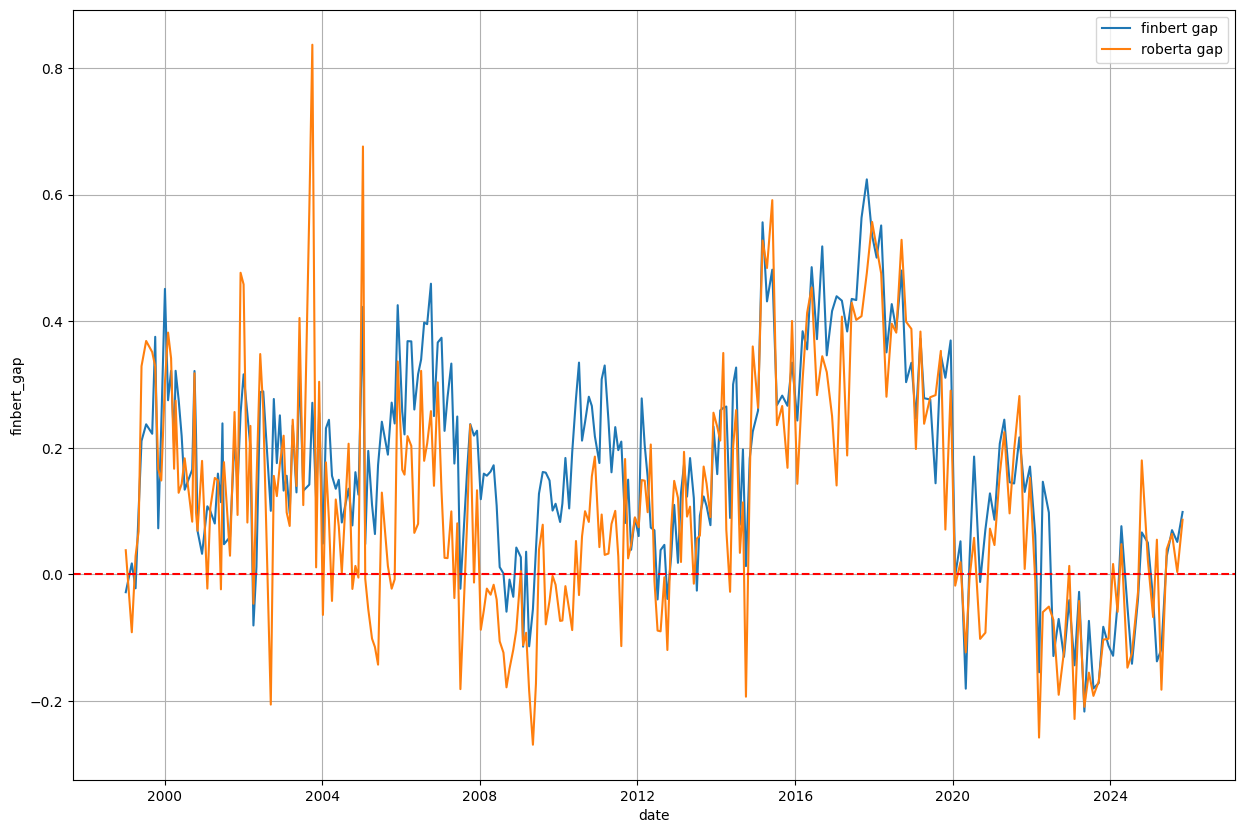

In [48]:
plt.figure(figsize=(15,10))
sns.lineplot(data=data, x=data.index, y="finbert_gap", label="finbert gap")
sns.lineplot(data=data, x=data.index, y="roberta_gap", label="roberta gap")
plt.axhline(color="red",linestyle="dashed")
plt.grid()

In [ ]:
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'DE2Y', 'DE10Y', 'IT2Y', 'FR2Y',
       'ES2Y', 'ES10Y', 'FR10Y', 'IT10Y', 'STOXX50_y', 'MRO', 'DF announced',
       'DF effective', 'Wu-Xia shadow rate', 'MRO announced', 'MRO effective',
       'finbert_max', 'roberta_max', 'finbert_mean', 'roberta_mean',
       'finbert_min', 'roberta_min', 'finbert_std', 'roberta_std', 'MRO_diff',
       'roberta_mean_diff', 'finbert_mean:11'],
      dtype='str')

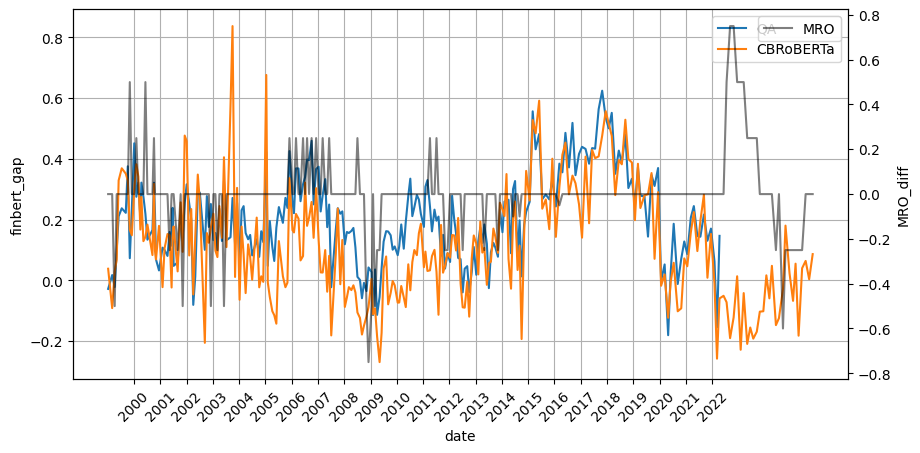

In [65]:
fig, ax = plt.subplots()
fig.set_figwidth(10)
data["MRO_diff"] = data["MRO announced"] - data["MRO"]
#data["sentiment_gap"] = 
sns.lineplot(
    data.loc[:"2022-04-30"].rolling(4).mean(),
    x="date",
    y=data["finbert_gap"],
    label="QA",
    ax=ax,
)
sns.lineplot(
    data,
    x="date",
    y=data["roberta_gap"],
    label="CBRoBERTa",
    ax=ax,
)

sns.lineplot(
    data,
    x="date",
    y=data["MRO_diff"],
    label="MRO",
    color="black",
    alpha=0.5,
    ax=ax.twinx(),
)
ax.set_xticks([f"{year}-01-01" for year in range(2000, 2023, 1)], [str(year) for year in range(2000, 2023, 1)],rotation=45)
ax.grid()

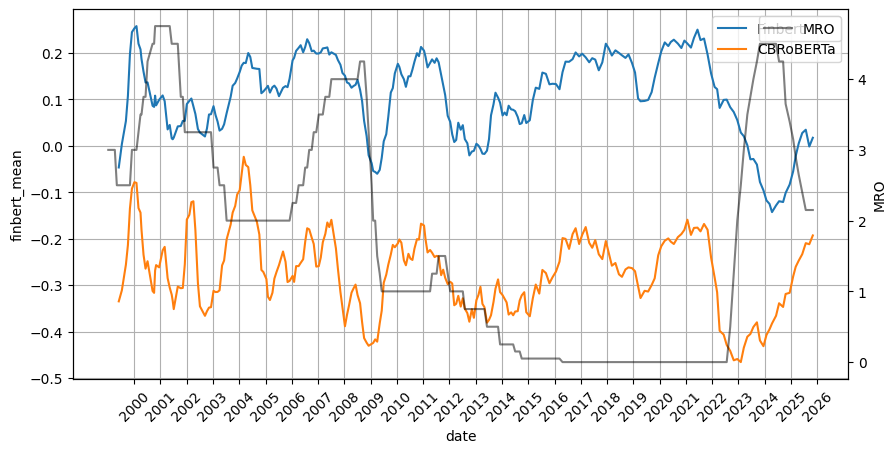

In [52]:
WITH_LABEL = False
data = return_data(
    IS_QA_division=False,
    qa_options="just_answers",
    with_label=WITH_LABEL,
    word_limit=350,
    market_data="all",
).set_index("date")
sentiment_columns = (
    data[
        sorted(
            [
                c
                for c in list(data.columns)
                if any(x in c for x in ["finbert", "roberta"])
            ],
            key=lambda x: tuple(reversed(x.split("_"))),
        )
    ]
).columns
fig, ax = plt.subplots()
fig.set_figwidth(10)
data["MRO_diff"] = data["MRO announced"] - data["MRO"]
sns.lineplot(
    data,
    x="date",
    y=data["finbert_mean"].rolling(5).mean(),
    label="Finbert",
    ax=ax,
)
sns.lineplot(
    data,
    x="date",
    y=data["roberta_mean"].rolling(5).mean(),
    label="CBRoBERTa",
    ax=ax,
)

sns.lineplot(
    data,
    x="date",
    y="MRO",
    label="MRO",
    color="black",
    alpha=0.5,
    ax=ax.twinx(),
)
ax.set_xticks([f"{year}-01-01" for year in range(2000, 2027, 1)], [str(year) for year in range(2000, 2027, 1)],rotation=45)
ax.grid()

date
1999-01-07         NaN
1999-03-04         NaN
1999-04-08         NaN
1999-05-06         NaN
1999-06-02         NaN
                ...   
2025-04-17   -0.293526
2025-06-05   -0.340396
2025-07-24   -0.241056
2025-09-11   -0.319115
2025-10-30   -0.239798
Name: roberta_mean, Length: 272, dtype: float64

<Axes: xlabel='finbert_mean', ylabel='MRO_diff'>

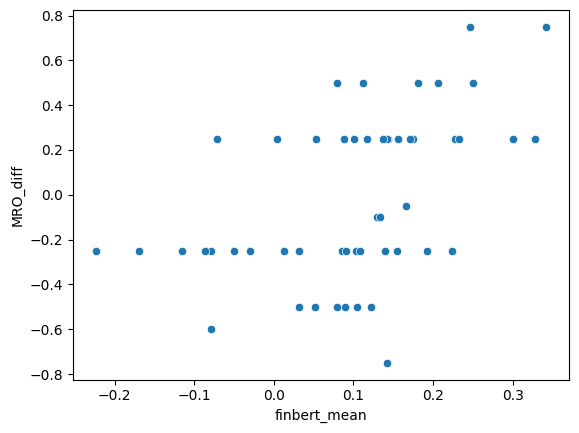

In [53]:
sns.scatterplot(data.query("MRO_diff != 0"), x=data["finbert_mean"].shift(11), y="MRO_diff")

In [56]:
data["finbert_mean:11"] = data["finbert_mean"].shift(11)
data.query("MRO_diff != 0")[["finbert_mean:11","MRO_diff"]].corr()

,finbert_mean:11,MRO_diff
finbert_mean:11,1.000000,0.487446
MRO_diff,0.487446,1.000000


In [61]:
data['sentiment_gap'] = data['finbert_IS_mean'] - data['finbert_QA_mean']
data["roberta_QA_mean_diff"] = data["roberta_QA_mean"].diff()

<Axes: xlabel='roberta_IS_mean', ylabel='Wu-Xia shadow rate'>

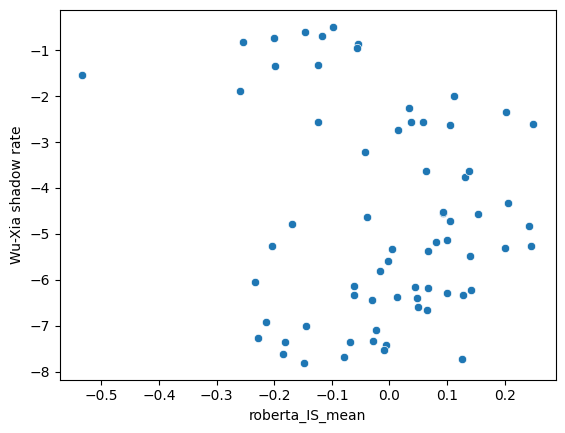

In [62]:
sns.scatterplot(data.loc['2014-01-01':'2021-12-31'], x="roberta_IS_mean",y='Wu-Xia shadow rate')

In [63]:
# Zameraj sa na obdobie 'Zero Lower Bound'
zlb_period = data.loc['2014-01-01':'2021-12-31']
correlation_zlb = zlb_period.corr()['Wu-Xia shadow rate'].loc[sentiment_columns]
print(pd.DataFrame(correlation_zlb).sort_values("Wu-Xia shadow rate").to_csv())

,Wu-Xia shadow rate
finbert_QA_mean,-0.4934894892509869
roberta_QA_mean,-0.4193253661020595
roberta_QA_std,-0.15830372389821068
roberta_IS_min,-0.15649233311441343
roberta_IS_mean,-0.13431744861072858
roberta_QA_max,-0.0944415589301745
roberta_QA_min,-0.08194842804594996
finbert_IS_min,-0.0541662222406543
finbert_QA_std,-0.04964050295808801
finbert_IS_mean,-0.049008239477211335
finbert_QA_min,-0.04779960666239741
finbert_IS_std,-0.040547466354107234
finbert_QA_max,-0.032447711330632435
roberta_IS_max,0.0160922427245429
roberta_IS_std,0.05440298280791908
finbert_IS_max,0.13272447842811105



In [66]:
# Zameraj sa na obdobie 'Zero Lower Bound'
before_zlb_period = data.loc[:'2014-01-01']
correlation_bzlb = before_zlb_period.corr()['MRO_diff'].loc[sentiment_columns]
print(pd.DataFrame(correlation_bzlb).to_csv())

,MRO_diff
finbert_IS_max,0.07544728882107057
roberta_IS_max,0.313115277457937
finbert_QA_max,0.050102407519274535
roberta_QA_max,0.15678666434768457
finbert_IS_mean,0.3875287724295077
roberta_IS_mean,0.25888416920032975
finbert_QA_mean,0.22515033002529852
roberta_QA_mean,0.13735910184605404
finbert_IS_min,0.12584541290960466
roberta_IS_min,0.011368125956181457
finbert_QA_min,0.17108476895848493
roberta_QA_min,-0.02817966242883614
finbert_IS_std,-0.28068926641221115
roberta_IS_std,0.20646742856010472
finbert_QA_std,-0.15969373635739517
roberta_QA_std,0.11436099972631217



In [67]:
# Zameraj sa na obdobie 'Zero Lower Bound'
after_zlb_period = data.loc['2021-12-31':]
correlation_azlb = after_zlb_period.corr()['MRO_diff'].loc[sentiment_columns]
print(pd.DataFrame(correlation_azlb).to_csv())

,MRO_diff
finbert_IS_max,-0.17164076346820178
roberta_IS_max,-0.2628256126287375
finbert_QA_max,-0.07054979829688336
roberta_QA_max,-0.4295881354327608
finbert_IS_mean,-0.25932079145466436
roberta_IS_mean,-0.5942101985373053
finbert_QA_mean,0.10174791039253764
roberta_QA_mean,-0.3483234034541775
finbert_IS_min,-0.09267486179213673
roberta_IS_min,-0.253032427897766
finbert_QA_min,-0.06328189395936029
roberta_QA_min,-0.3114377414681117
finbert_IS_std,-0.2813919227090378
roberta_IS_std,-0.42192650913227386
finbert_QA_std,0.11636717598196909
roberta_QA_std,-0.33071378342197555



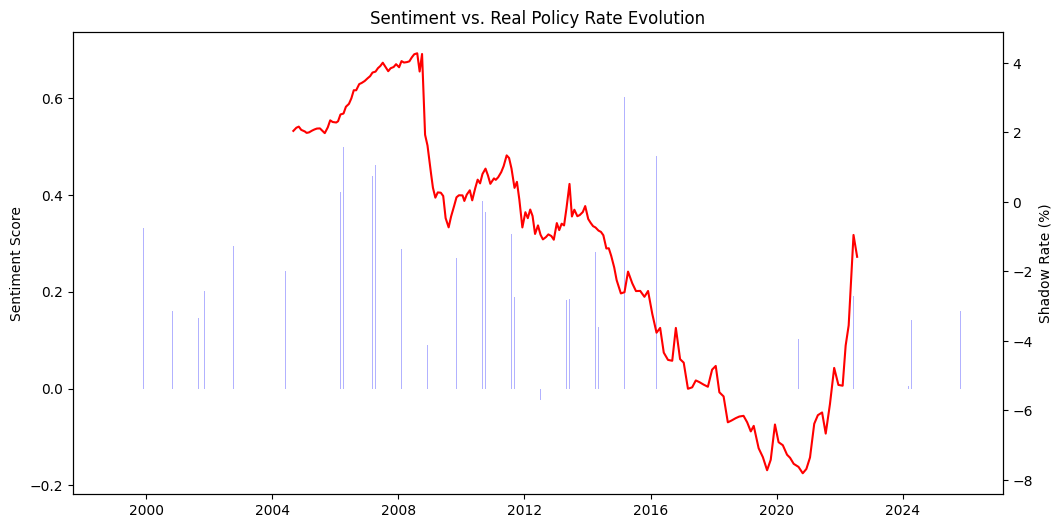

In [68]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Os X: Čas, Os Y1: Sentiment
ax1.bar(data.index, data['finbert_IS_mean'], color='blue', alpha=0.3, label='QA Sentiment')
ax1.set_ylabel('Sentiment Score')

# Druhá os Y2: Zmena sadzieb (Shadow rate alebo Euribor)
ax2 = ax1.twinx()
ax2.plot(data.index, data['Wu-Xia shadow rate'], color='red', label='Shadow Rate')
ax2.set_ylabel('Shadow Rate (%)')

plt.title("Sentiment vs. Real Policy Rate Evolution")
plt.show()

sentiment_decile
0.0    68
3.0    68
1.0    68
2.0    67
Name: count, dtype: int64


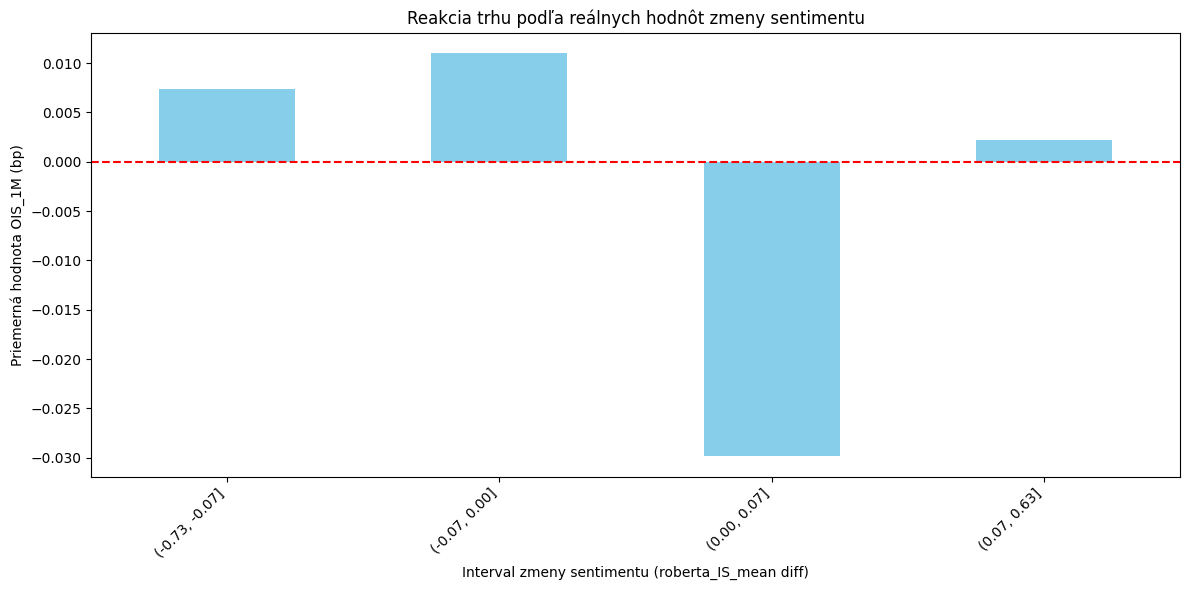

In [69]:
# 1. Príprava dát a výpočet zmeny sentimentu
new_data = data.sort_index()
COLUMN = 'roberta_IS_mean'
COLUMN_Y = "MRO_diff"
new_data[f"{COLUMN}_delta"] = data[COLUMN].diff()


# 2. Rozdelíme do decilov a ZÍSKAME HRANICE (bins)
# retbins=True nám vráti pole hodnôt, ktoré ohraničujú decily
new_data['sentiment_decile'], bins = pd.qcut(new_data[f"{COLUMN}_delta"], 4, retbins=True, labels=False)
print(new_data['sentiment_decile'].value_counts())
# 3. Výpočet priemeru pre každý decil
decile_analysis = new_data.groupby('sentiment_decile')[COLUMN_Y].mean()

# 4. Vytvorenie pekných labels pre os x (formát: "od, do")
# bins obsahuje 11 hodnôt pre 5 intervalov
bin_labels = [f"({bins[i]:.2f}, {bins[i+1]:.2f}]" for i in range(len(bins)-1)]

# 5. Vizualizácia
plt.figure(figsize=(12, 6))
ax = decile_analysis.plot(kind='bar', color='skyblue')

plt.axhline(0, color='red', linestyle='--')

# Nastavenie x-ticks na reálne hodnoty sentimentu
plt.xticks(range(4), bin_labels, rotation=45, ha='right')

plt.title("Reakcia trhu podľa reálnych hodnôt zmeny sentimentu")
plt.xlabel(f"Interval zmeny sentimentu ({COLUMN} diff)")
plt.ylabel("Priemerná hodnota OIS_1M (bp)")

plt.tight_layout()
plt.show()

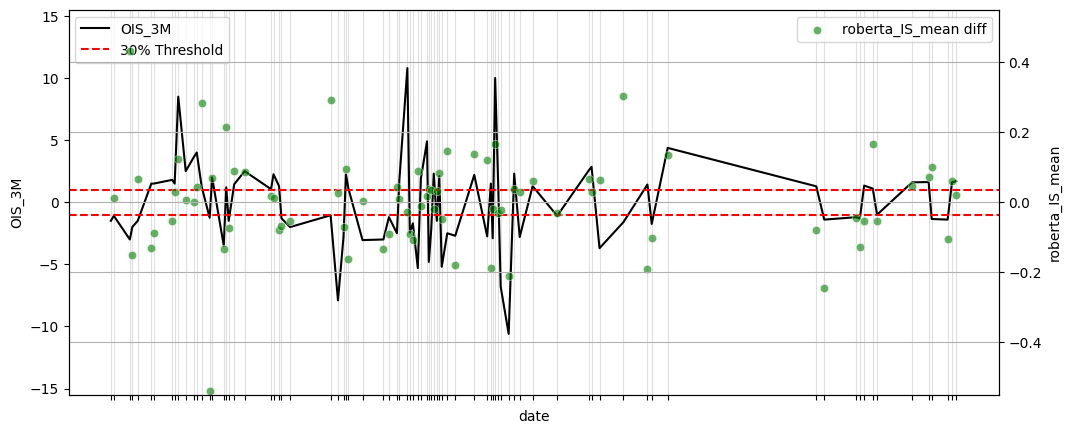

In [71]:
# 1. Časový rad s vyznačeným thresholdom
threshold = data["OIS_3M"].abs().quantile(0.7)
data["OIS_3M_above_threshold"] = data["OIS_3M"].abs() > threshold
new_data = data.query("OIS_3M_above_threshold")
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    new_data, x="date", y="OIS_3M", label="OIS_3M", color="black", alpha=1, ax=ax
)
ax.set_ylim(-15.5,15.5)
ax2 = ax.twinx()
sns.scatterplot(new_data,x="date", y=new_data["roberta_IS_mean"].diff(),alpha=0.6, label="roberta_IS_mean diff", color="green", ax=ax2)
ax2.set_ylim(-0.55,0.55)
ax.axhline(threshold, color="red", linestyle="--", label="30% Threshold")
ax.axhline(-threshold, color="red", linestyle="--")
ax.legend(loc="upper left")
ax2.grid()
ax.set_xticks(new_data.index,"")
ax.grid(axis="x",alpha=0.4)
None

1.003510951995851


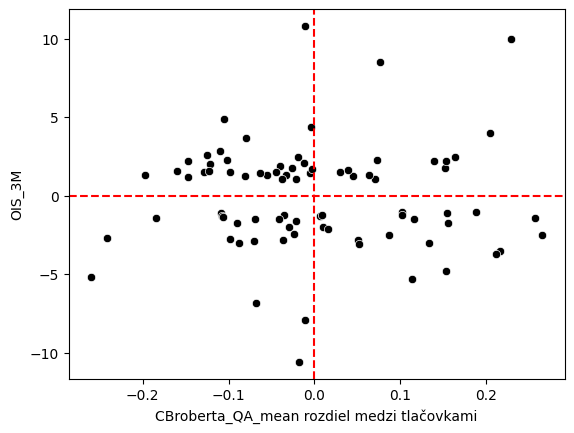

In [72]:
COLUMN_Y = "OIS_3M"
COLUMN = "roberta_QA_mean"

threshold = data[COLUMN_Y].abs().quantile(0.7)
data[f"{COLUMN_Y}_above_threshold"] = data[COLUMN_Y].abs() > threshold
new_data = data.query(f"{COLUMN_Y}_above_threshold")

plt.axhline(0,linestyle="dashed",color="red")
plt.axvline(0,linestyle="dashed",color="red")
sns.scatterplot(
    new_data, x=new_data[COLUMN].diff(), y=COLUMN_Y, color="black", alpha=1
)
plt.xlabel(f"CB{COLUMN} rozdiel medzi tlačovkami")
print(threshold)

In [ ]:
print("Autokorelácia (lag 1):", data['finbert_IS_MP_mean_diff'].autocorr())